In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings

warnings.filterwarnings('ignore')
print('✅ Library berhasil diimport')

✅ Library berhasil diimport


In [6]:
# Memuat dataset
df = pd.read_csv('fitness_workout_dataset_3800_rows.csv')
print(f'Shape dataset: {df.shape}')

# Menampilkan 5 baris pertama
display(df.head())

# Informasi dataset (tipe data dan missing values)
print("\n--- Info Dataset ---")
df.info()

# Ringkasan statistik
display(df.describe())

Shape dataset: (3800, 16)


,user_id,age,weight_kg,height_cm,workout_duration_min,workout_type,calories_burned,avg_heart_rate,sleep_hours,steps,active_minutes,resting_heart_rate,vo2_max,stress_level,hydration_liters,recovery_score
0,1,56,56.4,178.6,87,Strength,261,144,5.8,15410,170,62,34.3,1,1.25,75.0
1,2,46,88.3,187.3,73,Yoga,203,149,5.6,8164,111,48,37.7,3,2.33,53.7
2,3,32,50.0,168.9,76,Strength,266,145,9.3,9787,50,76,37.7,8,2.31,74.4
3,4,25,70.8,165.1,42,Cardio,399,129,5.8,17924,31,50,47.5,6,2.75,92.3
4,5,38,76.1,173.0,79,Strength,127,70,7.9,14518,153,70,40.2,3,2.06,99.2



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               3800 non-null   int64  
 1   age                   3800 non-null   int64  
 2   weight_kg             3800 non-null   float64
 3   height_cm             3800 non-null   float64
 4   workout_duration_min  3800 non-null   int64  
 5   workout_type          3800 non-null   object 
 6   calories_burned       3800 non-null   int64  
 7   avg_heart_rate        3800 non-null   int64  
 8   sleep_hours           3800 non-null   float64
 9   steps                 3800 non-null   int64  
 10  active_minutes        3800 non-null   int64  
 11  resting_heart_rate    3800 non-null   int64  
 12  vo2_max               3800 non-null   float64
 13  stress_level          3800 non-null   int64  
 14  hydration_liters      3800 non-null   float64
 15 

,user_id,age,weight_kg,height_cm,workout_duration_min,calories_burned,avg_heart_rate,sleep_hours,steps,active_minutes,resting_heart_rate,vo2_max,stress_level,hydration_liters,recovery_score
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,1900.50000,38.730526,74.758974,174.541658,68.836842,401.979211,119.097105,7.023053,11059.703947,94.626053,64.522895,44.848237,5.059474,2.521750,70.037684
std,1097.10984,12.054322,14.368790,14.256016,28.923244,176.043711,34.880019,1.736589,5150.049754,49.065142,11.608467,8.649703,2.581983,0.872072,17.231082
min,1.00000,18.000000,50.000000,150.000000,20.000000,100.000000,60.000000,4.000000,2000.000000,10.000000,45.000000,30.000000,1.000000,1.000000,40.100000
25%,950.75000,28.000000,62.300000,162.375000,43.000000,249.750000,89.000000,5.500000,6637.500000,53.000000,54.000000,37.300000,3.000000,1.760000,55.100000
50%,1900.50000,39.000000,74.600000,174.300000,69.000000,403.000000,119.000000,7.000000,11113.000000,94.000000,65.000000,44.900000,5.000000,2.520000,70.200000
75%,2850.25000,49.000000,87.100000,186.600000,94.000000,556.000000,150.000000,8.600000,15488.000000,137.000000,74.000000,52.225000,7.000000,3.290000,84.900000
max,3800.00000,59.000000,100.000000,200.000000,119.000000,699.000000,179.000000,10.000000,19994.000000,179.000000,84.000000,60.000000,9.000000,4.000000,100.000000


In [7]:
# 1. Menghapus kolom yang bukan fitur prediktif (user_id tidak memiliki korelasi logika dengan vo2_max)
df_clean = df.drop(columns=['user_id'])

# 2. Memisahkan target (y) dan fitur (X)
X = df_clean.drop(columns=['vo2_max'])
y = df_clean['vo2_max']

# 3. One-Hot Encoding untuk kolom kategorikal (workout_type)
# Parameter drop_first=False digunakan agar bentuk kolom tetap utuh/eksplisit saat deployment
X = pd.get_dummies(X, columns=['workout_type'], drop_first=False)

# 4. MENYIMPAN URUTAN KOLOM FITUR (Sangat penting untuk Streamlit!)
feature_columns = X.columns.tolist()

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Standardisasi Data (StandardScaler)
scaler = StandardScaler()

# Fit hanya pada data training untuk menghindari data leakage, lalu transform keduanya
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kembalikan ke format DataFrame agar lebih mudah dilacak (Opsional tapi praktik yang baik)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("✅ Data Preparation Selesai")
print(f"Jumlah kolom fitur input: {len(feature_columns)}")
print("Daftar fitur siap latih:", feature_columns)

✅ Data Preparation Selesai
Jumlah kolom fitur input: 17
Daftar fitur siap latih: ['age', 'weight_kg', 'height_cm', 'workout_duration_min', 'calories_burned', 'avg_heart_rate', 'sleep_hours', 'steps', 'active_minutes', 'resting_heart_rate', 'stress_level', 'hydration_liters', 'recovery_score', 'workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Strength', 'workout_type_Yoga']


📊 Hasil Evaluasi Model XGBoost:
RMSE     : 8.9887
MAE      : 7.7538
R2 Score : -0.0901


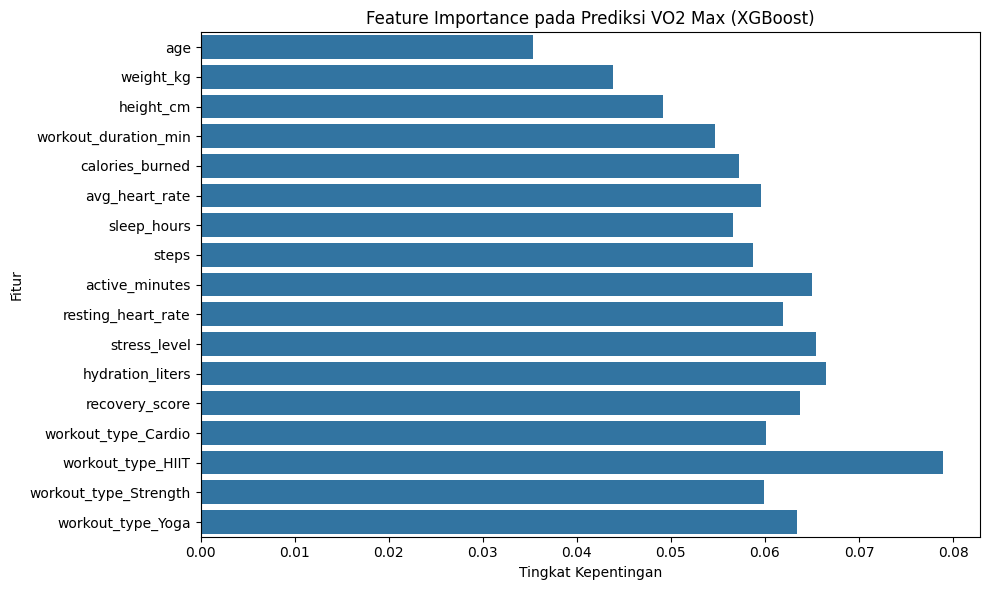

In [8]:
# Inisialisasi dan melatih model XGBoost
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Prediksi menggunakan data testing
y_pred = xgb_model.predict(X_test_scaled)

# Evaluasi performa model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Hasil Evaluasi Model XGBoost:")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"R2 Score : {r2:.4f}")

# (Opsional) Plot Feature Importance untuk melihat fitur yang paling berpengaruh
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_model.feature_importances_, y=feature_columns)
plt.title('Feature Importance pada Prediksi VO2 Max (XGBoost)')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [9]:
# 1. Simpan Model XGBoost
with open('vo2max_xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# 2. Simpan Scaler (agar skala input pengguna di web sama dengan skala saat model dilatih)
with open('vo2max_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Simpan Daftar Kolom Fitur (untuk memastikan kolom dummy Streamlit cocok 100% dengan model)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print('✅ BINGO! Ketiga file pkl (vo2max_xgboost_model.pkl, vo2max_scaler.pkl, dan feature_columns.pkl) berhasil dibuat dan siap diunduh dari Colab.')

✅ BINGO! Ketiga file pkl (vo2max_xgboost_model.pkl, vo2max_scaler.pkl, dan feature_columns.pkl) berhasil dibuat dan siap diunduh dari Colab.


In [10]:
import pickle

# Membuka dan membaca isi feature_columns.pkl
with open('feature_columns.pkl', 'rb') as file:
    features = pickle.load(file)

print("Jumlah Fitur:", len(features))
print("Daftar Fitur Lengkap:")
print(features)

Jumlah Fitur: 17
Daftar Fitur Lengkap:
['age', 'weight_kg', 'height_cm', 'workout_duration_min', 'calories_burned', 'avg_heart_rate', 'sleep_hours', 'steps', 'active_minutes', 'resting_heart_rate', 'stress_level', 'hydration_liters', 'recovery_score', 'workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Strength', 'workout_type_Yoga']
